# Assignment : 1
```
Anik Mandal, 18-07-24
```

## Q1: Program to roundoff numbers to two significant digits

In [1]:
def roundoff(num, nsig=2):
    '''
    -----Inputs---------
    num  : float/int | any number
    nsig : int | number of significant digits we want
    ----Output----------
    new_num : float/int | number after rounding off
    '''
    # finding the location of decimal and most significant digit in the number.
    digs = list(str(num))
    dec_loc = digs.index('.')
    
    for i in range(len(digs)):
        if digs[i] != '0' and digs[i] != '.':
            max_sig_loc = i
            break
            
    # shifting whole number such that first significant digit will be in 1st decimal place
    if num < 1:
        p =  dec_loc - max_sig_loc + 1
        num_shift = num / 10 ** p
    else:
        p = dec_loc - max_sig_loc 
        num_shift = num / 10 ** p 
        
    
    num_shift = num_shift * 10 **(nsig)
    
    if num_shift - int(num_shift) > 0.5:        # incrementing the number if the fraction is >0.5
        num_shift = num_shift + 1
    elif num_shift - int(num_shift) == 0.5:        # incrementing the number if the fraction is =0.5 and least number is odd
        if int(num_shift%2) == 1:
            num_shift = num_shift + 1
    
    new_num = int(num_shift) * 10**(p-nsig)        # new number after rounding off
    
    return new_num

In [2]:
# Inputs:
nums = [0.0094, 0.0167, 13.155, 19.168]
nsig = 2

for num in nums:
    new_num = roundoff(num, nsig)
    print('Rounding off {} to {} significant digits: {}'.format(num, nsig, new_num))


Rounding off 0.0094 to 2 significant digits: 0.0094
Rounding off 0.0167 to 2 significant digits: 0.017
Rounding off 13.155 to 2 significant digits: 13
Rounding off 19.168 to 2 significant digits: 19


## Q2: Program to generate sample random number between 1 and 100 and to find mean, median, mode and standard deviation of the sample

In [3]:
import os

# function to generate random number between 0 and 1
def gen_random(n=4):
    '''
    -----INPUT----------
    n : int | byte number
    -----OUTPUT---------
    a : int | random number between 0 and 1
    '''
    a = os.urandom(n)
    a = int.from_bytes(a, 'little')
    a = a/(2**(8*n)-1)
    return a

# function to generate random integer between a and b
def gen_randn(a, b):
    '''
    -----INPUT----------
    a : int | lower limit
    b : int | upper limit
    -----OUTPUT---------
    n : int | random integer between a and b
    '''
    n = gen_random()
    n = a + n * (b-a + 1) - 0.5
    if n-int(n) < 0.5:
        return int(n)
    else :
        return int(n+1)
    
    

In [4]:
# function to calculate mean of a sample
def mean(sample):
    '''
    -----INPUT----------
    sample : list | sample of data
    -----OUTPUT---------
    avg : float | mean of the sample
    '''
    s = 0
    for n in sample:
        s  += n
    return s/len(sample)

# function to calculate median of a sample
def median(sample):
    '''
    -----INPUT----------
    sample : list | sample of data
    -----OUTPUT---------
    median : float/int | median of the sample 
    '''
    s = sorted(sample)
    if len(s)%2 == 1:
        return s[(len(s)//2)]
    else:
        return (s[(len(s)-1)//2] + s[len(s)//2])/2

# function to calculate mode of a sample
def mode(sample):
    '''
    -----INPUT----------
    sample : list | sample of data
    -----OUTPUT---------
    max_freq_s : list | list of mode values of the sample
    '''
    freq_dict = {}
    for s in sample:
        if s in freq_dict:
            freq_dict[s] += 1
        else:
            freq_dict[s] = 1

    max_freq = max(freq_dict.values())
    max_freq_s = [s for s, count in freq_dict.items() if count == max_freq]
    return [max_freq_s, max_freq]

# function to calculate standard deviation of a sample
def sd(sample):
    '''
    -----INPUT----------
    sample : list | sample of data
    -----OUTPUT---------
    sd : float | standard deviaion of the sample
    '''
    s = 0
    avg = mean(sample)
    for n in sample:
        s += (n-avg) * (n-avg)
    sd = (s/(len(sample)-1))**0.5
    return sd
    

In [5]:
# sample generation and statistical calculations
a, b = 1, 100  # limits
nsample = 2**12  # no. of samples
rand_sample = [gen_randn(a, b) for i in range(nsample)]

avg_ = mean(rand_sample)
median_ = median(rand_sample)
mode_ = mode(rand_sample)
sd_ = sd(rand_sample)

print('Mean of the sample : {}'.format(avg_))
print('Median of the sample : {}'.format(median_))
print('Mode/modes of the sample : {}, frequency: {}'.format(mode_[0], mode_[1]))
print('Standard deviation of the sample : {}'.format(sd_))

Mean of the sample : 49.845458984375
Median of the sample : 49.0
Mode/modes of the sample : [42, 71, 34], frequency: 57
Standard deviation of the sample : 29.154270209312966


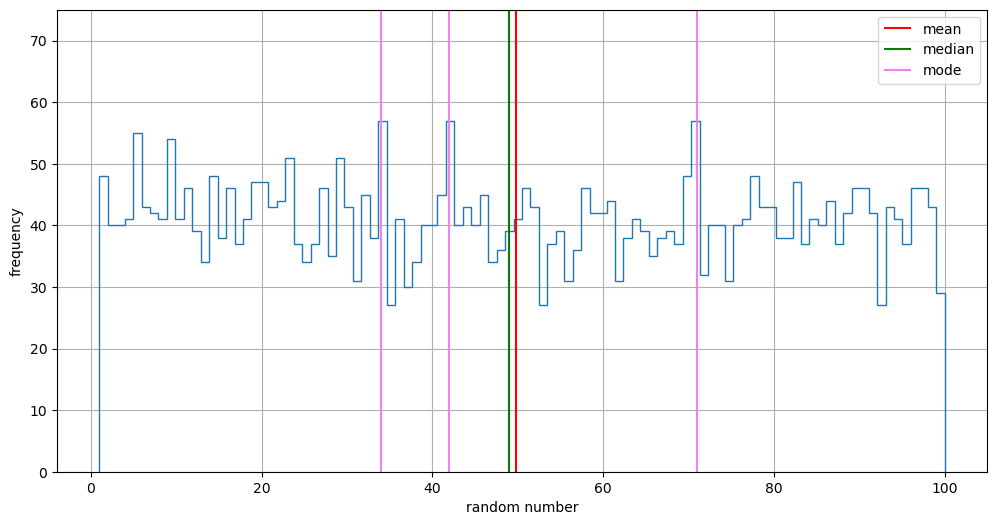

In [6]:
# ploting the sample distribution and statstical quantities for visualization
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(12,6))

plt.hist(rand_sample, bins=100, histtype='step')
plt.xlabel('random number')
plt.ylabel('frequency')
plt.ylim([0, 75])
plt.vlines([avg_], ymin=0, ymax=75, colors='red', label='mean')
plt.vlines([median_], ymin=0, ymax=75, colors='green', label='median')
plt.vlines(mode_[0], ymin=0, ymax=75, colors='violet', label='mode')
plt.legend(loc=1)
plt.grid()
plt.show()